<table width="100%">
  <tr>
    <td align="left" valign="middle" width="100%">
      <img src="../docs/assets/logo_bristol.png" alt="University of Bristol" width="200" />
    </td>
    <td align="right" valign="middle" width="100%">
      <img src="../docs/assets/logo_ufpe.png" alt="UFPE" width="130" />
      &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
      <img src="../docs/assets/logo_kunumi.png" alt="Kunumi" width="150" />
      &nbsp;&nbsp;
    </td>
  </tr>
</table>

---

In [ ]:
import subprocess
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    REPO_ROOT = Path('/content/latent-ability-ml')
    if not REPO_ROOT.exists():
        subprocess.check_call([
            'git',
            'clone',
            'https://github.com/manuelfjr/latent-ability-ml.git',
            str(REPO_ROOT),
        ])

    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        'numpy',
        'pandas',
        'matplotlib',
        'scipy',
        'scikit-learn',
        'seaborn',
        'joblib',
        'tqdm',
        'birt-gd',
    ])

    for candidate in [REPO_ROOT, REPO_ROOT / 'notebooks', REPO_ROOT / 'utils', REPO_ROOT / 'src']:
        candidate_str = str(candidate)
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)

    from nb_utils import set_root
    PROJECT_ROOT = REPO_ROOT
    print(f'Running in Colab with project root: {PROJECT_ROOT}')
else:
    from nb_utils import set_root
    PROJECT_ROOT = set_root(level=2)
    print(f'Running locally with project root: {PROJECT_ROOT}')


**Environment note.** Run the next code cell first. It loads the repository and the local modules needed for this notebook, especially when opening it in Google Colab.


# Answer 5: CLAIRE and Agreement-Based Evaluation on a Synthetic Dataset

This notebook provides one worked solution path for the Section 5 activity.


## Activity Goals

By the end of this notebook, you should be able to:

- generate a synthetic dataset with medium to high variability;
- fit a diverse pool of clustering models;
- build the response matrix `pij` from model agreement;
- train Beta4-IRT on `pij`;
- inspect model abilities, item difficulties, and item discriminations;
- generate ICCs and inspect representative individuals/items.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from birt import Beta4

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering, MeanShift, OPTICS
from sklearn.metrics import (
    adjusted_rand_score,
    mutual_info_score,
    silhouette_score,
    calinski_harabasz_score,
)

from utils.transform import TransformPairwise
from utils.handson import beta4_expected_response


## Task 1: Generate a synthetic dataset with medium to high variability

Build a dataset with enough heterogeneity to make clustering nontrivial.

Suggestions:

- use `make_blobs`; 
- choose at least 3 centers;
- use different `cluster_std` values;
- keep one group more dispersed than the others.

If you prefer, you may replace this with another synthetic dataset of your choice.


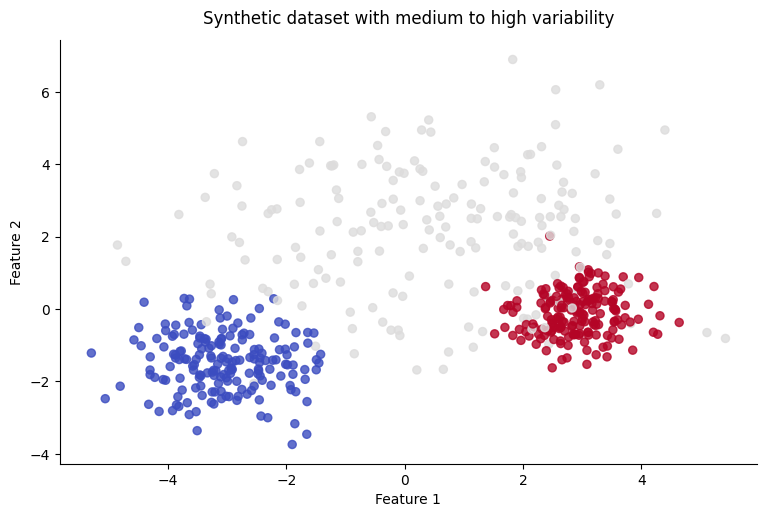

,feature_1,feature_2,label,instance_id
0,-3.494581,-0.960071,0,0
1,2.982257,0.488217,2,1
2,1.973279,3.630775,1,2
3,-1.141483,2.412145,1,3
4,-3.524170,-1.393768,0,4


In [3]:
X, y = make_blobs(
    n_samples=540,
    centers=[[-3.0, -1.5], [0.5, 2.0], [3.0, -0.2]],
    cluster_std=[0.8, 1.9, 0.55],
    random_state=24,
)

df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
df['label'] = y
df['instance_id'] = np.arange(len(df))

fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))
ax.scatter(df['feature_1'], df['feature_2'], c=df['label'], cmap='coolwarm', alpha=0.8, s=34)
ax.set_title('Synthetic dataset with medium to high variability', pad=12)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.spines[['top', 'right']].set_visible(False)
plt.show()

df.head()


## Task 2: Train a pool of clustering models

Create a model pool with different inductive biases. The disagreement between these models is what will later define the CLAIRE response matrix.


In [4]:
models = {
    **{f'KMeans_k_{k}': KMeans(n_clusters=k, random_state=1, n_init=20) for k in range(2, 6)},
    **{f'DBSCAN_eps_{eps:.2f}': DBSCAN(eps=float(eps), min_samples=6) for eps in [0.25, 0.45, 0.70, 0.95]},
    **{f'Spectral_k_{k}': SpectralClustering(n_clusters=k, random_state=1, assign_labels='kmeans') for k in range(2, 6)},
    'MeanShift': MeanShift(),
    'OPTICS_min_samples_6': OPTICS(min_samples=6),
}

results = []
partitions = pd.DataFrame(index=df['instance_id'], columns=models.keys())

for key, model in models.items():
    labels_pred = model.fit_predict(df[['feature_1', 'feature_2']].values)
    partitions[key] = labels_pred
    metrics = {
        'model': key,
        'adjusted_rand_score': adjusted_rand_score(df['label'], labels_pred),
        'mutual_info_score': mutual_info_score(df['label'], labels_pred),
    }
    try:
        metrics |= {
            'silhouette_score': silhouette_score(df[['feature_1', 'feature_2']], labels_pred),
            'calinski_harabasz_score': calinski_harabasz_score(df[['feature_1', 'feature_2']], labels_pred),
        }
    except Exception:
        metrics |= {
            'silhouette_score': np.nan,
            'calinski_harabasz_score': np.nan,
        }
    results.append(metrics)

results = pd.DataFrame(results).sort_values('adjusted_rand_score', ascending=False)
results


,model,adjusted_rand_score,mutual_info_score,silhouette_score,calinski_harabasz_score
12,MeanShift,0.699369,0.762565,0.605148,1172.847203
5,DBSCAN_eps_0.45,0.691459,0.837519,0.246429,183.580695
2,KMeans_k_4,0.684927,0.820020,0.573036,1096.975599
9,Spectral_k_3,0.681378,0.754576,0.609676,1165.253068
1,KMeans_k_3,0.677066,0.749585,0.609913,1183.211363
3,KMeans_k_5,0.652647,0.850570,0.495237,991.286815
8,Spectral_k_2,0.497138,0.513891,0.584281,913.502878
0,KMeans_k_2,0.478761,0.494654,0.590767,969.099526
4,DBSCAN_eps_0.25,0.475955,0.567615,0.245861,235.662415
10,Spectral_k_4,0.183702,0.320607,0.138243,69.857956


## Task 3: Generate the response matrix `pij`

Use the agreement between the clustering models to construct the response matrix used by CLAIRE.


In [5]:
# The CLAIRE response matrix must be built from pairwise agreement, so we use TransformPairwise.
tp = TransformPairwise(1)
pij = tp.generate_pij_matrix(partitions)

print(pij.shape)
pij.head()


100%|██████████| 540/540 [00:00<00:00, 996.66it/s] 

(540, 14)


,KMeans_k_2,KMeans_k_3,KMeans_k_4,KMeans_k_5,DBSCAN_eps_0.25,DBSCAN_eps_0.45,DBSCAN_eps_0.70,DBSCAN_eps_0.95,Spectral_k_2,Spectral_k_3,Spectral_k_4,Spectral_k_5,MeanShift,OPTICS_min_samples_6
0,0.765663,0.783074,0.783930,0.751962,0.673469,0.760525,0.475953,0.442557,0.780791,0.784787,0.601827,0.594406,0.781932,0.521336
1,0.699158,0.767090,0.765663,0.763665,0.706579,0.749108,0.565006,0.546739,0.688312,0.766234,0.630084,0.630084,0.766234,0.512488
2,0.570144,0.688883,0.670044,0.658913,0.610104,0.622378,0.343228,0.349793,0.572428,0.682318,0.662909,0.663765,0.697160,0.482232
3,0.541459,0.685315,0.651349,0.651920,0.603967,0.637648,0.325103,0.343085,0.555159,0.684744,0.648780,0.602255,0.684173,0.490081
4,0.764664,0.782075,0.782931,0.750963,0.672470,0.759526,0.474954,0.441558,0.779792,0.783788,0.600828,0.593407,0.780933,0.508349


## Task 4: Train Beta4-IRT

Fit Beta4 on the response matrix and inspect the estimated abilities of the models.


In [6]:
birt = Beta4(
    learning_rate=1,
    epochs=10_000,
    n_respondents=pij.shape[1],
    n_items=pij.shape[0],
    n_inits=1000,
    n_workers=1,
    random_seed=1,
    tol=10**(-8),
    set_priors=True,
)

birt.fit(pij.values)

abilities = pd.DataFrame(
    {
        'model': partitions.columns,
        'ability': birt.abilities,
    }
).sort_values('ability', ascending=False)

abilities


 39%|███▉      | 3893/10000 [00:08<00:13, 465.47it/s]


Model converged at the 3893th epoch


,model,ability
12,MeanShift,0.528894
1,KMeans_k_3,0.528879
9,Spectral_k_3,0.527883
2,KMeans_k_4,0.524704
3,KMeans_k_5,0.505809
5,DBSCAN_eps_0.45,0.498137
8,Spectral_k_2,0.483643
0,KMeans_k_2,0.483198
4,DBSCAN_eps_0.25,0.440376
10,Spectral_k_4,0.432579


## Task 5: Compare abilities with standard clustering metrics

Merge the estimated abilities with standard clustering metrics and inspect how the rankings compare.


In [7]:
comparison = results.merge(abilities, on='model', how='left').sort_values('ability', ascending=False)
comparison


,model,adjusted_rand_score,mutual_info_score,silhouette_score,calinski_harabasz_score,ability
0,MeanShift,0.699369,0.762565,0.605148,1172.847203,0.528894
4,KMeans_k_3,0.677066,0.749585,0.609913,1183.211363,0.528879
3,Spectral_k_3,0.681378,0.754576,0.609676,1165.253068,0.527883
2,KMeans_k_4,0.684927,0.820020,0.573036,1096.975599,0.524704
5,KMeans_k_5,0.652647,0.850570,0.495237,991.286815,0.505809
1,DBSCAN_eps_0.45,0.691459,0.837519,0.246429,183.580695,0.498137
6,Spectral_k_2,0.497138,0.513891,0.584281,913.502878,0.483643
7,KMeans_k_2,0.478761,0.494654,0.590767,969.099526,0.483198
8,DBSCAN_eps_0.25,0.475955,0.567615,0.245861,235.662415,0.440376
9,Spectral_k_4,0.183702,0.320607,0.138243,69.857956,0.432579


## Task 6: Inspect item difficulties and discriminations

Now move from model-level analysis to item-level analysis.

In particular, inspect:

- which instances are estimated as the most difficult;
- which instances have the largest positive discrimination;
- whether difficult items are concentrated in the most dispersed or overlapping regions.


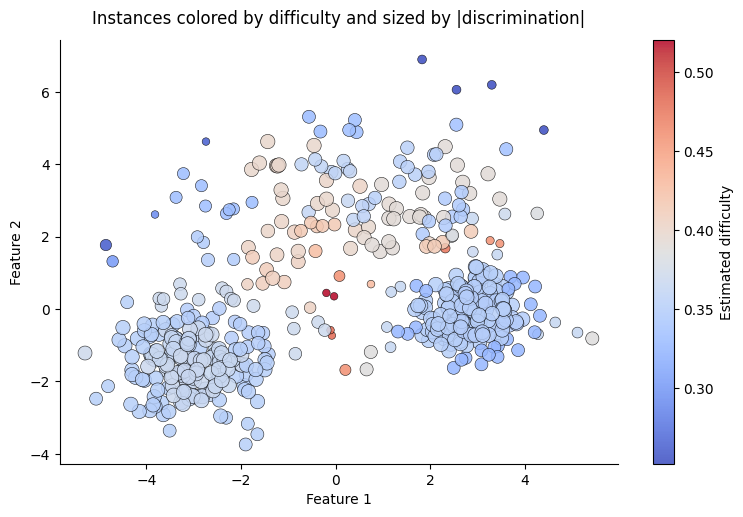

,instance_id,feature_1,feature_2,label,difficulty,discrimination,abs_discrimination
416,416,-0.196372,0.441773,1,0.520003,0.096137,0.096137
412,412,-0.033653,0.348162,1,0.520003,0.096137,0.096137
312,312,-0.108983,-0.586341,1,0.482060,0.045575,0.045575
215,215,-0.081169,-0.735118,1,0.482060,0.045575,0.045575
95,95,2.316024,1.677339,1,0.475079,0.393768,0.393768
250,250,0.079657,0.907296,1,0.459901,0.520618,0.520618
226,226,0.205178,-1.686160,1,0.458988,0.535201,0.535201
265,265,3.263578,1.887446,1,0.458033,0.292020,0.292020
105,105,3.469418,1.805715,1,0.458033,0.292020,0.292020
58,58,0.745654,0.684985,1,0.427932,0.256721,0.256721


In [8]:
item_summary = df[['instance_id', 'feature_1', 'feature_2', 'label']].copy()
item_summary['difficulty'] = birt.difficulties
item_summary['discrimination'] = birt.discriminations
item_summary['abs_discrimination'] = np.abs(item_summary['discrimination'])

sizes = np.clip(item_summary['abs_discrimination'] * 120, 30, 220)

fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))
sc = ax.scatter(
    item_summary['feature_1'],
    item_summary['feature_2'],
    c=item_summary['difficulty'],
    s=sizes,
    cmap='coolwarm',
    alpha=0.85,
    edgecolor='black',
    linewidth=0.4,
)
fig.colorbar(sc, ax=ax, label='Estimated difficulty')
ax.set_title('Instances colored by difficulty and sized by |discrimination|', pad=12)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.spines[['top', 'right']].set_visible(False)
plt.show()

item_summary.sort_values('difficulty', ascending=False).head(10)


## Task 7: Generate ICCs for representative items

Select at least two representative instances and compare their ICCs.

Suggested idea:

- one highly difficult item;
- one easy item;
- optionally one item with unusual discrimination.


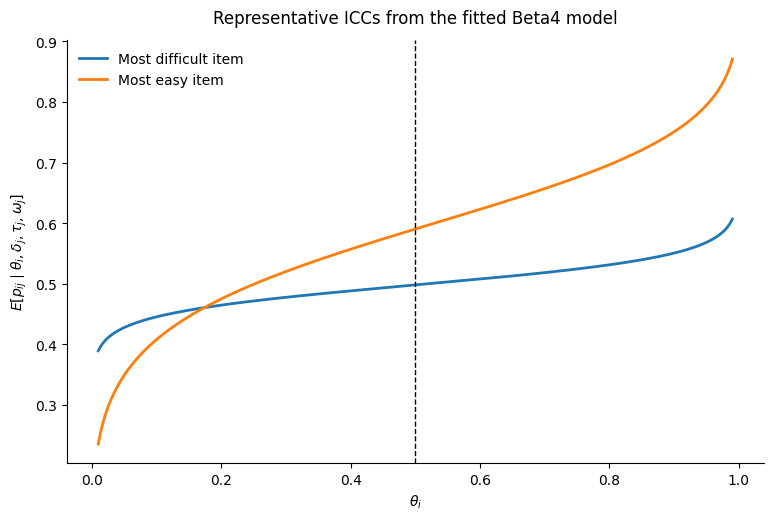

,instance_id,feature_1,feature_2,difficulty,discrimination
most_difficult,412,-0.033653,0.348162,0.520003,0.096137
most_easy,94,1.825795,6.890994,0.251857,0.335790


In [9]:
theta_grid = np.linspace(0.01, 0.99, 300)
idx_difficult = int(np.argmax(birt.difficulties))
idx_easy = int(np.argmin(birt.difficulties))

selected_items = item_summary.loc[[idx_difficult, idx_easy], ['instance_id', 'feature_1', 'feature_2', 'difficulty', 'discrimination']].copy()
selected_items.index = ['most_difficult', 'most_easy']

curves = {}
for label_name, row in selected_items.iterrows():
    curves[label_name] = beta4_expected_response(
        theta=theta_grid,
        difficulty=row['difficulty'],
        discrimination_sign=np.sign(row['discrimination']),
        discrimination_magnitude=np.abs(row['discrimination']),
    )

fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))
ax.plot(theta_grid, curves['most_difficult'], label='Most difficult item', linewidth=2)
ax.plot(theta_grid, curves['most_easy'], label='Most easy item', linewidth=2)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1)
ax.set_title('Representative ICCs from the fitted Beta4 model', pad=12)
ax.set_xlabel(r'$\theta_i$')
ax.set_ylabel(r'$E[p_{ij} \mid \theta_i, \delta_j, \tau_j, \omega_j]$')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.show()

selected_items


## Task 8: Inspect the individual items in more detail

Pick one representative item from the previous task and inspect it more carefully.

Suggested questions:

- Where is this item located in the feature space?
- Is it close to overlap or to a dispersed region?
- Does its ICC match what you would expect from its estimated difficulty and discrimination?


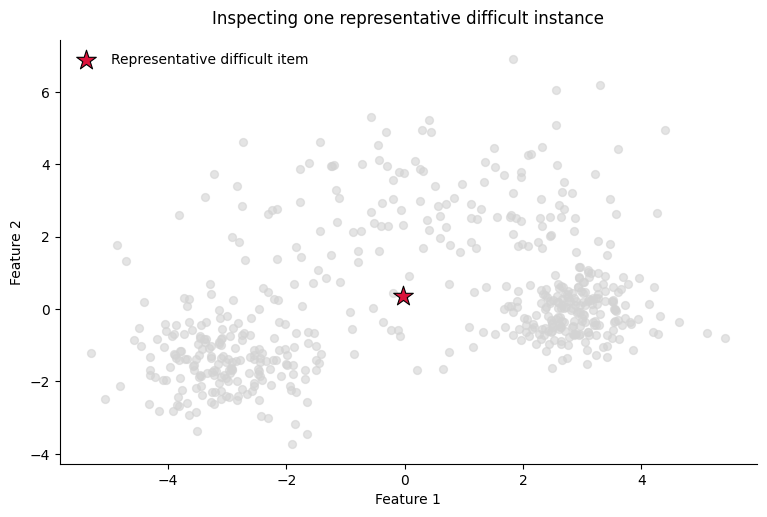

instance_id           412.000000
feature_1              -0.033653
feature_2               0.348162
label                   1.000000
difficulty              0.520003
discrimination          0.096137
abs_discrimination      0.096137
Name: 412, dtype: float64

In [10]:
representative_item = item_summary.loc[idx_difficult]

fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))
ax.scatter(df['feature_1'], df['feature_2'], c='lightgray', s=32, alpha=0.6)
ax.scatter(
    representative_item['feature_1'],
    representative_item['feature_2'],
    c='crimson',
    s=220,
    marker='*',
    edgecolor='black',
    linewidth=0.8,
    label='Representative difficult item',
)
ax.set_title('Inspecting one representative difficult instance', pad=12)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.show()

representative_item


## Reflection Questions

1. Which models achieved the highest ability according to Beta4-IRT?
2. Do the ability rankings agree with the standard clustering metrics?
3. Where are the most difficult items located in the dataset?
4. How do the ICCs differ between easy and difficult items?
5. What does this tell you about the value of latent-variable analysis in clustering evaluation?
